In [1]:
import pandas
#import matplotlib.pyplot as plt

In [3]:
# https://vizier.cds.unistra.fr/viz-bin/VizieR-4
file = "data_clean/vizier_I_239_hip_main_LimpiezaNaNPlx.tsv"

# leer .tsv
df = pandas.read_csv(
    file,              # nombre y ruta del archivo
    sep = '\t',         # símbolo de separación de columnas
    nrows = 118218,    # número de filas que se leerán
    index_col = 'HIP', # nombre de la columna índice
)

# dataframe
print( type(df) )

df

<class 'pandas.core.frame.DataFrame'>


,recno,Proxy,RAhms,DEdms,Vmag,VarFlag,r_Vmag,RAICRS,DEICRS,AstroRef,...,BD,CoD,CPD,(V-I)red,SpType,r_SpType,HIPep,Erratum,_RA.icrs,_DE.icrs
HIP,,,,,,,,,,,,,,,,,,,,,
1,1,NaN,00 00 00.22,+01 05 20.4,9.10,NaN,H,0.000912,1.089013,NaN,...,B+00 5077,NaN,NaN,0.66,F5,S,HIPep,Erratum,0.000899,1.089009
2,2,NaN,00 00 00.91,-19 29 55.8,9.27,NaN,G,0.003797,-19.498837,+,...,B-20 6688,NaN,NaN,1.04,K3V,4,HIPep,Erratum,0.004265,-19.498840
3,3,NaN,00 00 01.20,+38 51 33.4,6.61,NaN,G,0.005008,38.859286,NaN,...,B+38 5108,NaN,NaN,0.00,B9,S,HIPep,Erratum,0.005024,38.859279
4,4,NaN,00 00 02.01,-51 53 36.8,8.06,NaN,H,0.008382,-51.893546,NaN,...,NaN,NaN,P-52 12237,0.43,F0V,2,HIPep,Erratum,0.008629,-51.893546
5,5,NaN,00 00 02.39,-40 35 28.4,8.55,NaN,H,0.009965,-40.591224,NaN,...,NaN,C-41 15372,P-41 9991,0.95,G8III,2,HIPep,Erratum,0.009973,-40.591202
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118318,118214,NaN,23 59 51.30,+11 40 25.4,6.99,1.0,H,359.963744,11.673709,NaN,...,B+10 5018,NaN,NaN,1.56,K2,S,HIPep,Erratum,359.963738,11.673714
118319,118215,NaN,23 59 53.74,-22 25 41.4,8.23,NaN,G,359.973913,-22.428180,NaN,...,NaN,C-23 18108,P-23 8366,0.70,G2V,4,HIPep,Erratum,359.974304,-22.428113
118320,118216,NaN,23 59 54.25,+05 57 23.9,7.59,NaN,H,359.976057,5.956638,NaN,...,B+05 5245,NaN,NaN,0.98,K0,S,HIPep,Erratum,359.976109,5.956552


In [4]:
# agrupar las magnitudes por orden en rango
min_vmag = int( df['Vmag'].min() )
max_vmag = int( df['Vmag'].max() )

# frecuencia de las magnitudes
vmag_freq = df['Vmag'].value_counts( 
    bins = range( min_vmag - 5, max_vmag ) 
).sort_index()

print(min_vmag, max_vmag)

vmag_freq

-1 13


(-6.001, -5.0]        0
(-5.0, -4.0]          0
(-4.0, -3.0]          0
(-3.0, -2.0]          0
(-2.0, -1.0]          1
(-1.0, 0.0]           3
(0.0, 1.0]           11
(1.0, 2.0]           34
(2.0, 3.0]          128
(3.0, 4.0]          340
(4.0, 5.0]         1103
(5.0, 6.0]         3397
(6.0, 7.0]        10402
(7.0, 8.0]        25527
(8.0, 9.0]        40746
(9.0, 10.0]       23124
(10.0, 11.0]       6649
(11.0, 12.0]       1870
Name: count, dtype: int64

In [34]:
vmag_freq.index = range(min_vmag - 4, max_vmag)
vmag_freq

-5        0
-4        0
-3        0
-2        0
-1        1
0         3
1        11
2        34
3       128
4       341
5      1107
6      3416
7     10496
8     25857
9     41943
10    24546
11     7396
12     2183
13      471
Name: count, dtype: int64

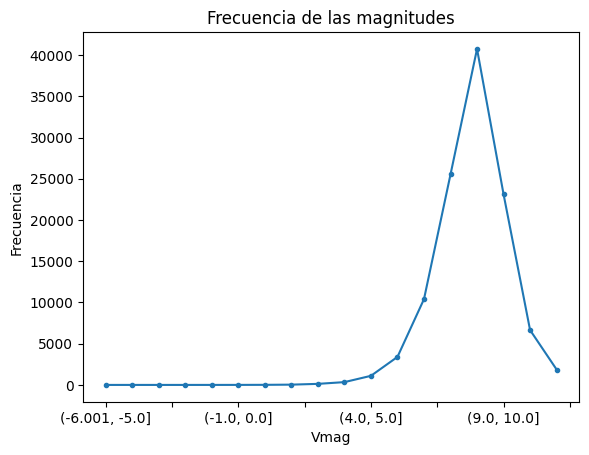

In [5]:
import matplotlib.pyplot as plt

vmag_freq.plot(
    style = '.-', title = 'Frecuencia de las magnitudes',
    xlabel = 'Vmag', ylabel = 'Frecuencia'
)

plt.show()

In [8]:
df["Vmag"].describe()

count    113710.000000
mean          8.330849
std           1.295276
min          -1.440000
25%           7.612500
50%           8.410000
75%           9.100000
max          13.570000
Name: Vmag, dtype: float64

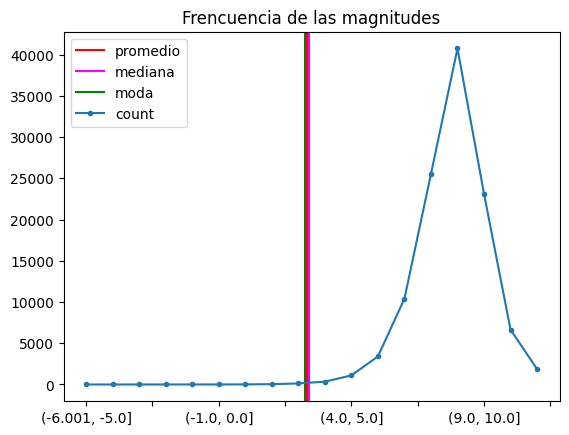

In [10]:
# Gráficas de las medidas estadísticas
plt.axvline( df['Vmag'].mean(), color = 'red', label = 'promedio' )

plt.axvline( df['Vmag'].median(), color = 'magenta', label = 'mediana' )

plt.axvline( df['Vmag'].mode()[0], color ='green', label = 'moda' )

# Gráfica de la frecuencia de las edades
vmag_freq.plot( style = ".-", title = 'Frencuencia de las magnitudes' )

# Leyenda y mostrar gráfica
plt.legend()

plt.show()

In [11]:
df['Vmag'].skew()

np.float64(-0.41269775835454836)

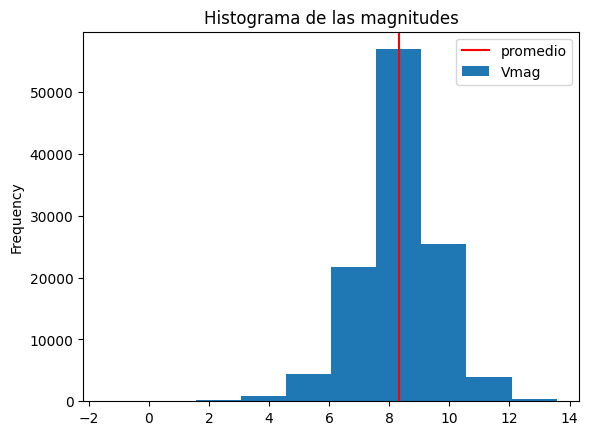

In [12]:
# Gráficas de las medidas estadísticas
plt.axvline( df['Vmag'].mean(), color = 'red', label = 'promedio' )

# Gráfica de la frecuencia de las edades
df['Vmag'].plot.hist( title = 'Histograma de las magnitudes' )

# Leyenda y mostrar gráfica
plt.legend()
plt.show()

In [13]:
df['Vmag'].std()

np.float64(1.2952760488062454)

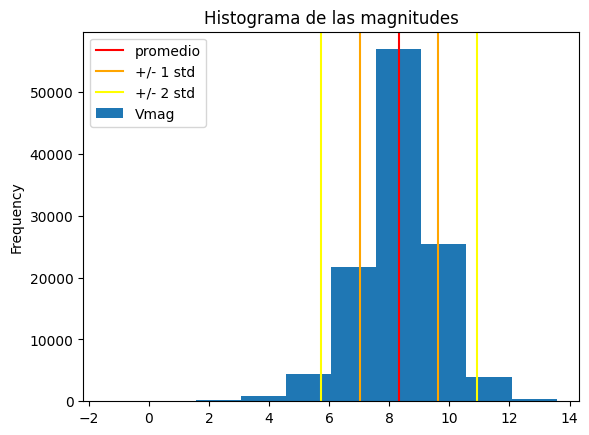

In [14]:
# Gráficas de las medidas estadísticas
plt.axvline( df['Vmag'].mean(), color = 'red', label = 'promedio' )
plt.axvline( df['Vmag'].mean() + df['Vmag'].std(), color = 'orange', label = '+/- 1 std' )
plt.axvline( df['Vmag'].mean() - df['Vmag'].std(), color = 'orange' )
plt.axvline( df['Vmag'].mean() + df['Vmag'].std() * 2, color = 'yellow', label = '+/- 2 std' )
plt.axvline( df['Vmag'].mean() - df['Vmag'].std() * 2, color = 'yellow' )

# Gráfica de la frecuencia de las edades
df['Vmag'].plot.hist( title = 'Histograma de las magnitudes' )

# Leyenda y mostrar gráfica
plt.legend()
plt.show()

## 1. Astronomical Coordinate system

We start by looking at what portion of the sky is covered by the Hipparchos mission. To do this we use the astronomical coordinate systems,

- The right ascension
- The declination

Think of right ascension as the longitude and declination as the latitude of the stars in the sky with respect to what Astronomers define the [celestial sphere](https://en.wikipedia.org/wiki/Celestial_sphere), an imaginary sphere at infinity such that stars at these distance appear to remain fixed in the sky.

[This is](https://skyandtelescope.org/astronomy-resources/right-ascension-declination-celestial-coordinates/) an article by one of our fellow astronomers. I strongly recommend you to read it through if you are new to Astronomy.

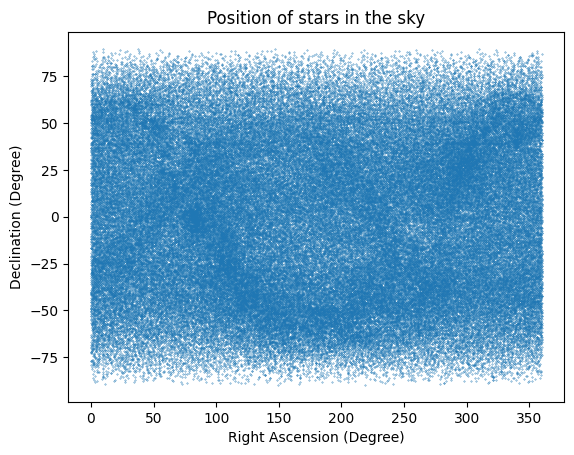

In [59]:
# estilo para las figuras
newfigparams = {
    "figure.figsize": (10,4),
    "figure.dpi": 150,
    "axes.titlesize": 20,
    "axes.labelsize": 11,
    "ytick.labelsize": 11,
    "xtick.labelsize": 11,
    "legend.fontsize": 12,
    "legend.frameon": True,
    "lines.linewidth": 1
}
#plt.rcParams.update(newfigparams)
#plt.style.use("dark_background")

fig, ax = plt.subplots()
ax.plot(df["RAICRS"], df["DEICRS"], 'o', markersize = 0.3)
#ax.plot(x, y)

plt.xlabel("Right Ascension (Degree)")
plt.ylabel("Declination (Degree)")
plt.title ("Position of stars in the sky")

plt.show()

The stars in the catalogue covers pretty much the entire sky. Notice that in the plot we see regions of over densities and underdensities. These are very common terms used in Astronomy to see how well is the sky covered by a particular mission. I will not go any deeper into these concepts here. For the time being, consider over densities as regions where you see more stars than the average and the underdensities as regions where you see lesser number of stars than the average.

## 2. Proper Motion of stars

We now visualize the proper motion of the stars as captured by the Hipparchos mission.

Distant stars on the celestial sphere appear to remain fixed, however, most of the stars in the solar neighborhood appear to move across the celestial sphere since these stars are closer. This apparent motion of stars with respect to the fixed stars in the background is called the [proper motion](https://en.wikipedia.org/wiki/Proper_motion).

Proper motion is measured along the Right Ascension (pmRA) and along the Declination (pmDE) and these are measured in mas per year (mas year−1), where mas is milliarcseconds, a common unit used to measure very small angles in the sky.

1mas=10−3arcsecond

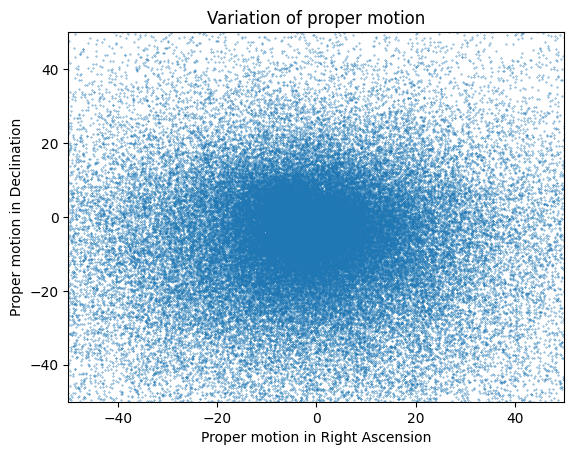

In [60]:
plt.plot(df["pmRA"], df["pmDE"], 'o', markersize = 0.3)
plt.xlabel("Proper motion in Right Ascension")
plt.ylabel("Proper motion in Declination")
plt.title ("Variation of proper motion")
plt.xlim(-50, 50)
plt.ylim(-50, 50)
plt.show()



Could you think of a reason why the proper motion is centered around 0?

[Think in terms of earth's motion in the solar system and the solar system's motion around the galactic center]


## Cuántas estrellas en el catálogo de Hipparcos tienen la Magnitud Absoluta similar al Sol?

In [ ]:
sun_absMag = 4.9
sun_appMag = -26.7

In [109]:
# https://vizier.cds.unistra.fr/viz-bin/VizieR-4
file = "data_clean/vizier_I_239_hip_main.tsv"

# leer .csv
dfAbsMagSimilarToSun = pandas.read_csv(
    file,              # nombre y ruta del archivo
    sep = '\t',        # símbolo de separación de columnas
    nrows = 118218,    # número de filas que se leerán
    index_col = 'HIP', # nombre de la columna índice
)

# dataframe
print( type(dfAbsMagSimilarToSun) )

dfAbsMagSimilarToSun.head()

<class 'pandas.core.frame.DataFrame'>


,RAhms,DEdms,Vmag,Plx,ABSmag,Pc,Ly,X,Y,Z
HIP,,,,,,,,,,
1,00 00 00.22,+01 05 20.4,9.10,3.54,1.845016,282.485876,921.355367,282.434852,0.004495,5.368848
2,00 00 00.91,-19 29 55.8,9.27,21.90,5.972221,45.662100,148.931416,43.043300,0.002853,-15.241449
3,00 00 01.20,+38 51 33.4,6.61,2.81,-1.146468,355.871886,1160.711032,277.113585,0.024221,223.277539
4,00 00 02.01,-51 53 36.8,8.06,7.75,2.506509,129.032258,420.851355,79.628969,0.011649,-101.531034
5,00 00 02.39,-40 35 28.4,8.55,2.87,0.839409,348.432056,1136.445296,264.589185,0.046019,-226.710076


In [37]:
# Tabla vacía con valores igual
dfAbsMagSimilarToSun[dfAbsMagSimilarToSun['ABSmag'] == 4.9]

,RAhms,DEdms,Vmag,Plx,ABSmag,Pc,Ly,X,Y,Z
HIP,,,,,,,,,,


In [38]:
# 104960 estrellas menores a la Magnitud Absoluta del Sol
absMag_lessThan = dfAbsMagSimilarToSun[dfAbsMagSimilarToSun['ABSmag'] <= 4.9]
absMag_lessThan.shape

(104960, 10)

In [39]:
absMag_lessThan['ABSmag'].describe()

count    104960.000000
mean          1.287874
std           1.999284
min         -13.310000
25%           0.169672
50%           1.358402
75%           2.747133
max           4.899733
Name: ABSmag, dtype: float64

In [40]:
# 104960 estrellas menores a la Magnitud Absoluta del Sol
absMag_higherThan = dfAbsMagSimilarToSun[dfAbsMagSimilarToSun['ABSmag'] >= 4.9]
absMag_higherThan.shape

(8750, 10)

In [41]:
absMag_higherThan['ABSmag'].describe()

count    8750.000000
mean        6.536500
std         1.499897
min         4.900054
25%         5.368397
50%         6.094087
75%         7.307435
max        15.449015
Name: ABSmag, dtype: float64

### Estas dos estrellas tienen la Magnitud Absoluta lo más cercana al Sol

In [61]:
higherCloseToSun = absMag_higherThan['ABSmag'].min()
lessCloseToSun = absMag_lessThan['ABSmag'].max()

#dfAbsMagSimilarToSun.loc[[70880, 76696]]
dfAbsMagSimilarToSun.loc[ (dfAbsMagSimilarToSun['ABSmag'] == higherCloseToSun) | (dfAbsMagSimilarToSun['ABSmag'] == lessCloseToSun) ]

,RAhms,DEdms,Vmag,Plx,ABSmag,Pc,Ly,X,Y,Z
HIP,,,,,,,,,,
70880,14 29 43.22,+35 28 04.8,10.22,8.63,4.900054,115.874855,377.937196,-74.941226,-57.359306,67.236186
76696,15 39 39.47,+35 39 06.2,9.80,10.47,4.899733,95.510984,311.518434,-44.610024,-63.507738,55.669211


In [89]:
# 7554 estrellas están por el umbral de la Magnitud absoluta 4 (4.90-4.00)
are_above = dfAbsMagSimilarToSun[(dfAbsMagSimilarToSun['ABSmag'] > 4) & (dfAbsMagSimilarToSun['ABSmag'] < 4.90)]
are_above['ABSmag'].describe()

count    7554.000000
mean        4.399836
std         0.257458
min         4.000017
25%         4.173664
50%         4.375367
75%         4.614076
max         4.899733
Name: ABSmag, dtype: float64

In [90]:
higherCloseToSun = are_above['ABSmag'].min()
lessCloseToSun = are_above['ABSmag'].max()
are_above['ABSmag'].sort_values( ascending=False )

HIP
76696     4.899733
12499     4.899385
109378    4.899103
51611     4.899008
111131    4.898947
            ...   
104580    4.000189
26387     4.000091
18973     4.000057
76400     4.000050
16884     4.000017
Name: ABSmag, Length: 7554, dtype: float64

In [91]:
are_above.sort_values('ABSmag', ascending=False)

,RAhms,DEdms,Vmag,Plx,ABSmag,Pc,Ly,X,Y,Z
HIP,,,,,,,,,,
76696,15 39 39.47,+35 39 06.2,9.80,10.47,4.899733,95.510984,311.518434,-44.610024,-63.507738,55.669211
12499,02 40 49.05,-22 57 22.4,9.93,9.86,4.899385,101.419878,330.790872,71.324602,60.283256,-39.556567
109378,22 09 29.82,-07 32 51.2,6.54,46.97,4.899103,21.290185,69.440026,18.699574,-9.786613,-2.796447
51611,10 32 35.23,-72 26 28.8,9.02,14.99,4.899008,66.711141,217.584923,-18.679345,7.491332,-63.602974
111131,22 30 47.24,+06 30 01.5,9.75,10.71,4.898947,93.370682,304.537628,85.830120,-35.207073,10.570556
...,...,...,...,...,...,...,...,...,...,...
104580,21 11 03.88,-63 41 05.4,8.65,11.75,4.000189,85.106383,277.582809,27.934404,-25.359435,-76.286726
26387,05 37 04.71,+20 21 34.1,9.30,8.71,4.000091,114.810563,374.465901,10.747384,107.100257,39.943636
18973,04 03 55.05,+39 44 21.0,10.71,4.55,4.000057,219.780220,716.834725,81.987440,147.783646,140.504088


In [88]:
# 8059 estrellas están por el umbral de la Magnitud absoluta 4 (4.99-4.90)
are_below = dfAbsMagSimilarToSun[(dfAbsMagSimilarToSun['ABSmag'] > 4.90) & (dfAbsMagSimilarToSun['ABSmag'] < 5)]
are_below['ABSmag'].describe()

count    505.000000
mean       4.950356
std        0.028076
min        4.900054
25%        4.927671
50%        4.948915
75%        4.973641
max        4.999775
Name: ABSmag, dtype: float64

In [106]:
# 8059 estrellas tienen la Magnitud Absoluta al Sol
len(are_below.index) + len(are_above.index)

8059

# Anexo: Estrellas Prominentes del Catálogo de Hipparcos
### https://es.wikipedia.org/wiki/Anexo:Estrellas_del_Cat%C3%A1logo_Hipparcos
### https://www.cosmos.esa.int/web/hipparcos/sample-tables-1

In [110]:
# https://vizier.cds.unistra.fr/viz-bin/VizieR-4
file = "data_clean/vizier_I_239_hip_main.tsv"

# leer .csv
dfAnexoProminente = pandas.read_csv(
    file,              # nombre y ruta del archivo
    sep = '\t',        # símbolo de separación de columnas
    nrows = 118218,    # número de filas que se leerán
    index_col = 'HIP', # nombre de la columna índice
)

# dataframe
print( type(dfAnexoProminente) )

dfAnexoProminente.head(2)

<class 'pandas.core.frame.DataFrame'>


,RAhms,DEdms,Vmag,Plx,ABSmag,Pc,Ly,X,Y,Z
HIP,,,,,,,,,,
1,00 00 00.22,+01 05 20.4,9.10,3.54,1.845016,282.485876,921.355367,282.434852,0.004495,5.368848
2,00 00 00.91,-19 29 55.8,9.27,21.90,5.972221,45.662100,148.931416,43.043300,0.002853,-15.241449


In [175]:
dict_hip_completo = {
    # HIP 1 ~ 10000
    667: "α Andromedae (Alpheratz o Sirrah)",
    746: "Caph",
    2081: "Ankaa",
    3179: "Shedir",
    3419: "β Ceti (Deneb Kaitos o Diphda)",
    3829: "Estrella de Van Maanen",
    5447: "β Andromedae (Mirach)",
    6686: "Ruchbah",
    7588: "α Eridani (Achernar)",
    8903: "Sheratan",
    9640: "Almaak",
    9884: "α Arietis (Hamal)",
    # HIP 10001 ~ 20000
    10826: "ο Ceti (Mira)",
    11767: "α Ursae Minoris (Polaris)",
    13847: "Acamar",
    14135: "Menkar",
    15863: "α Persei (Mirfak o Algenib)",
    17702: "Alcyone",
    18543: "Zaurak",
    # HIP 20001 ~ 30000
    21421: "α Tauri (Aldebarán)",
    24186: "Estrella de Kapteyn",
    21421: "Aldebaran",
    23015: "Hassaleh",
    23875: "Cursa",
    24436: "β Orionis (Rigel)",
    24608: "α Aurigae (Capella)",
    25336: "γ Orionis (Bellatrix)",
    25428: "β Tauri (Elnath)",
    25606: "Nihal",
    25930: "δ Orionis (Mintaka)",
    25985: "Arneb",
    26241: "Hatsya",
    26311: "ε Orionis (Alnilam)",
    26634: "Phact",
    26727: "ζ Orionis (Alnitak)",
    27366: "κ Orionis (Saiph)",
    27989: "α Orionis (Betelgeuse)",
    28360: "β Aurigae (Menkalinan)",
    # HIP 30001 ~ 40000
    30089: "Red Rectangle",
    30324: "β Canis Majoris (Mirzam o Murzim)",
    30438: "α Carinae (Canopo)",
    31681: "γ Geminorum (Alhena)",
    32349: "α Canis Majoris (Sirio)",
    33579: "ε Canis Majoris (Adhara)",
    34444: "δ Canis Majoris (Wezen)",
    35904: "Aludra",
    36188: "Gomeisa",
    36208: "Luyten's Star",
    36850: "α Geminorum (Cástor)",
    37279: "α Canis Minoris (Procyon)",
    37826: "β Geminorum (Pólux)",
    39429: "Naos",
    39953: "γ Velorum (Suhail o Regor)",
    # HIP 40001 ~ 50000
    41037: "ε Carinae (Avior)",
    42913: "δ Velorum",
    45238: "β Carinae (Miaplacidus)",
    45556: "Aspidiske",
    46390: "α Hydrae (Alphard)",
    49669: "α Leonis (Regulus)",
    # HIP 50001 ~ 60000
    50583: "γ Leonis (Algieba)",
    53910: "Merak",
    54035: "Lalande 21185",
    54061: "α Ursae Majoris (Dubhe)",
    54872: "δ Leonis (Duhr o Zosma)",
    54879: "θ Leonis (Chertan)",
    56997: "61 Ursae Majoris",
    57362: "β Leonis (Denébola)",
    57757: "β Virginis (Zavijava)",
    58001: "γ Ursae Majoris (Phecda)",
    59196: "δ Centauri",
    59774: "Megrez",
    # HIP 60001 ~ 70000
    60351: "12 Comae Berenices",
    60718: "α Crucis (Acrux)",
    60965: "Algorab",
    61084: "γ Crucis (Gacrux)",
    61359: "Kraz",
    61941: "Porrima",
    62434: "β Crucis (Becrux o Mimosa)",
    62956: "ε Ursae Majoris (Alioth)",
    63125: "Cor Caroli",
    63608: "ε Virginis (Vindemiatrix)",
    65378: "Mizar",
    65474: "α Virginis (Espiga)",
    65477: "Alcor",
    65835: "R Hydrae",
    66249: "ζ Virginis (Heze)",
    67301: "η Ursae Majoris (Alkaid o Benetnasch)",
    68702: "β Centauri (Hadar o Agena)",
    68756: "Thuban",
    68933: "θ Centauri (Menkent)",
    69673: "α Bootis (Arturo)",
    # HIP 70001 ~ 80000
    71681: "α Centauri B (Rigil Kentaurus o Toliman)",
    71683: "α Centauri A (Rigil Kentaurus o Toliman)",
    71860: "α Lupi (Kakkab o Men)",
    72607: "β Ursae Minoris (Kochab)",
    72622: "Zubenelgenubi",
    74785: "Zubeneschamali",
    75097: "γ Ursae Minoris (Pherkad)",
    77070: "Unukalhai",
    78401: "Dschubba",
    # HIP 80001 ~ 90000
    80763: "α Scorpii (Antares)",
    80816: "Kornephoros",
    82273: "α Trianguli Australis (Atria)",
    82396: "ε Scorpii (Wei)",
    84345: "Rasalgethi",
    85670: "Rastaban",
    85927: "λ Scorpii (Shaula)",
    86032: "α Ophiuchi (Rasalhague o Ras Alhague)",
    86228: "θ Scorpii (Sargas o Girtab)",
    86742: "Cebalrai",
    87833: "Etamin",
    87937: "Barnard's Star",
    88635: "Alnasl",
    89931: "Kaus Media",
    # HIP 90001 ~ 100000
    90185: "ε Sagittarii (Kaus Australis)",
    90496: "λ Sagittarii (Kaus Borealis)",
    91262: "α Lyrae (Vega)",
    92403: "Ross 154",
    92420: "Sheliak",
    92855: "σ Sagittarii (Nunki)",
    94114: "Alphekka Meridiana",
    94141: "Albaldah",
    95947: "Albireo",
    97278: "γ Aquilae (Tarazed)",
    97649: "α Aquilae (Altair)",
    98036: "Alshain",
    # HIP 100001 ~ 110000
    100453: "Sadr",
    100751: "α Pavonis (Peacock)",
    102098: "α Cygni (Deneb, Arided o Aridif)",
    105199: "Alderamin",
    105881: "ζ Capricorni (Marakk)",
    106278: "Sadalsuud",
    107315: "Enif",
    109074: "Sadalmelik",
    109268: "α Gruis (Alnair)",
    109358: "β Canum Venaticorum (Asterion o Chara)",
    110893: "Kruger 60",
    # HIP 110001 ~ 120000
    112122: "β Gruis (Gruid)",
    112158: "Matar",
    112247: "Babcock's Star",
    113368: "α Piscis Austrini (Fomalhaut)",
    113881: "Scheat",
    113963: "Markab",
  }
len(dict_hip_completo.keys())

142

In [176]:
dfAnexoProminenteLoc = dfAnexoProminente.loc[dict_hip_completo.keys()].sort_values('Pc', ascending=True)
dfAnexoProminenteLoc

,RAhms,DEdms,Vmag,Plx,ABSmag,Pc,Ly,X,Y,Z
HIP,,,,,,,,,,
71681,14 39 39.39,-60 50 22.1,1.35,742.12,5.702371,1.347491,4.394974,-0.503598,-0.421285,-1.176707
71683,14 39 40.90,-60 50 06.5,-0.01,742.12,4.342371,1.347491,4.394974,-0.503620,-0.421397,-1.176658
87937,17 57 48.97,+04 40 05.8,9.54,549.01,13.237901,1.821460,5.940872,-0.017299,-1.815335,0.148243
54035,11 03 20.61,+35 58 53.3,7.49,392.40,10.458645,2.548420,8.311922,-1.999506,0.504621,1.497257
32349,06 45 09.25,-16 42 47.3,-1.44,379.21,1.454399,2.637061,8.601034,-0.494399,2.476801,-0.758367
...,...,...,...,...,...,...,...,...,...,...
34444,07 08 23.49,-26 23 35.5,1.83,1.82,-6.869643,549.450549,1792.086813,-144.702678,470.425968,-244.246699
65835,13 29 42.82,-23 16 52.9,6.40,1.62,-2.552425,617.283951,2013.332099,-524.130381,-216.335077,-243.979413
112247,22 44 07.50,+55 35 21.2,8.83,1.40,-0.439360,714.285714,2329.712857,381.738381,-131.210207,589.290905


In [177]:
menoresA10pc = dfAnexoProminenteLoc[dfAnexoProminenteLoc['Pc'] < 10]
menoresA10pc

,RAhms,DEdms,Vmag,Plx,ABSmag,Pc,Ly,X,Y,Z
HIP,,,,,,,,,,
71681,14 39 39.39,-60 50 22.1,1.35,742.12,5.702371,1.347491,4.394974,-0.503598,-0.421285,-1.176707
71683,14 39 40.90,-60 50 06.5,-0.01,742.12,4.342371,1.347491,4.394974,-0.503620,-0.421397,-1.176658
87937,17 57 48.97,+04 40 05.8,9.54,549.01,13.237901,1.821460,5.940872,-0.017299,-1.815335,0.148243
54035,11 03 20.61,+35 58 53.3,7.49,392.40,10.458645,2.548420,8.311922,-1.999506,0.504621,1.497257
32349,06 45 09.25,-16 42 47.3,-1.44,379.21,1.454399,2.637061,8.601034,-0.494399,2.476801,-0.758367
92403,18 49 48.96,-23 50 08.8,10.37,336.48,13.004796,2.971945,9.693289,0.586251,-2.654494,-1.201011
37279,07 39 18.54,+05 13 39.0,0.40,285.93,2.681299,3.497359,11.406981,-1.462376,3.160924,0.318647
36208,07 27 24.16,+05 14 05.2,9.84,263.26,11.941924,3.798526,12.389265,-1.407873,3.510924,0.346565
24186,05 11 35.21,-45 00 16.2,8.86,255.26,10.894914,3.917574,12.777552,0.580783,2.708354,-2.770360


In [178]:
menoresA10pc.index

Index([ 71681,  71683,  87937,  54035,  32349,  92403,  37279,  36208,  24186,
       110893,   3829,  97649, 113368,  91262,  56997],
      dtype='int64', name='HIP')

## En el Cielo las Estrellas Hipparcos
### La estrella más lejana

In [142]:
# Abramson, Guillermo. (2013). La estrella más lejana. En el cielo las estrellas.
# Recuperado de: https://guillermoabramson.blogspot.com/2013/09/la-estrella-mas-lejana.html

from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

In [143]:
table = Table.read_table("data_clean/vizier_I_239_hip_main.tsv", sep='\t')
table.show(5)

HIP,RAhms,DEdms,Vmag,Plx,ABSmag,Pc,Ly,X,Y,Z
1,00 00 00.22,+01 05 20.4,9.1,3.54,1.84502,282.486,921.355,282.435,0.00449489,5.36885
2,00 00 00.91,-19 29 55.8,9.27,21.9,5.97222,45.6621,148.931,43.0433,0.00285276,-15.2414
3,00 00 01.20,+38 51 33.4,6.61,2.81,-1.14647,355.872,1160.71,277.114,0.0242212,223.278
4,00 00 02.01,-51 53 36.8,8.06,7.75,2.50651,129.032,420.851,79.629,0.0116488,-101.531
5,00 00 02.39,-40 35 28.4,8.55,2.87,0.839409,348.432,1136.45,264.589,0.0460195,-226.71


In [144]:
stars = table.select(0,6,3,5,4)
farthest_star = stars
max(farthest_star.column(1))

100000.0

In [145]:
app_mag = stars
min(app_mag.column(2))

-1.4399999999999999

In [146]:
app_mag.where(2, are.equal_to(-1.44))

HIP,Pc,Vmag,ABSmag,Plx
32349,2.63706,-1.44,1.4544,379.21


In [147]:
app_mag = stars
max(app_mag.column(2))

13.57

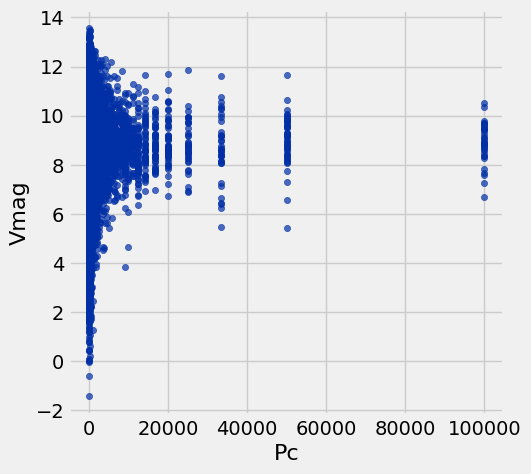

In [148]:
stars.scatter(1, 2)

In [149]:
stars.select(0,1,2).where(2, are.below_or_equal_to(6)).sort(1, descending=True)

HIP,Pc,Vmag
74941,50000,5.43
64094,33333.3,5.44
28716,10000,4.64
89341,9090.91,3.84
45675,5882.35,5.83
117447,5000,5.43
5926,4545.45,5.87
97757,4545.45,5.6
98863,4166.67,5.62
54751,3846.15,4.59


In [150]:
stars.where(1, are.above(40000)).show(5)

HIP,Pc,Vmag,ABSmag,Plx
1287,50000,9.11,-9.38485,0.02
2776,100000,9.68,-10.32,0.01
3216,50000,9.01,-9.48485,0.02
4043,100000,9.36,-10.64,0.01
4050,100000,7.82,-12.18,0.01


In [151]:
stars.where(1, are.equal_to(100000)).show(5)

HIP,Pc,Vmag,ABSmag,Plx
2776,100000,9.68,-10.32,0.01
4043,100000,9.36,-10.64,0.01
4050,100000,7.82,-12.18,0.01
10676,100000,8.77,-11.23,0.01
14880,100000,9.44,-10.56,0.01


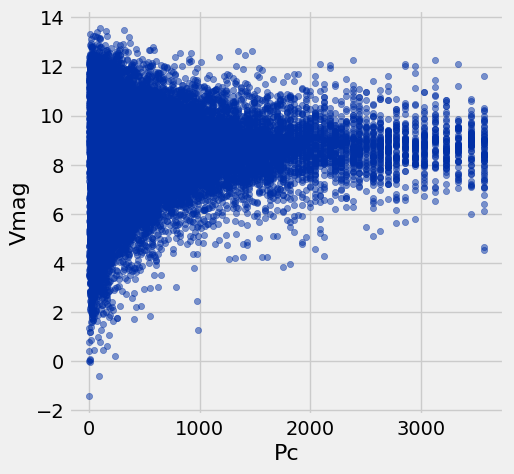

In [152]:
stars_2 = stars.where(1, are.below_or_equal_to(3600))
stars_2.scatter(1,2, alpha=0.5)

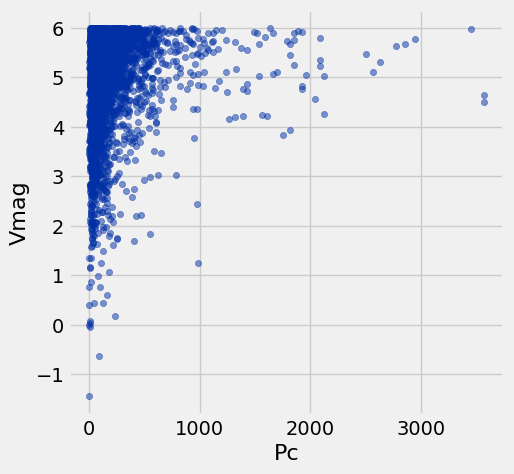

In [153]:
stars_3 = stars_2.where(1, are.below_or_equal_to(3600))
stars_3.where(2, are.below_or_equal_to(6)).scatter(1,2, alpha=0.5)

### HIP 66925 is the farthest and faintest star that we can see with naked eye

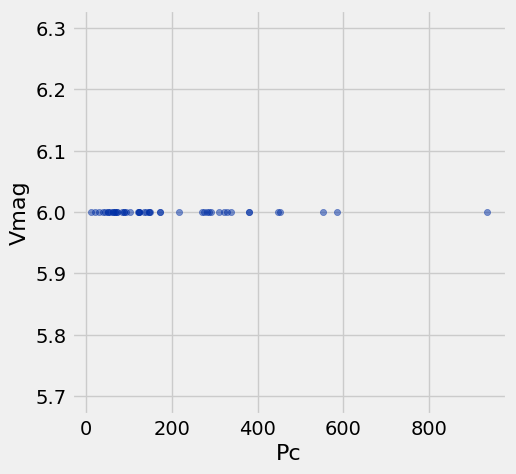

In [154]:
stars_2.select(0,1,2).where(2, are.equal_to(6)).sort(1, descending=True).scatter(1,2, alpha=0.5)

In [155]:
stars_2.select(0,1,2).where(2, are.equal_to(6)).sort(1, descending=True).show(1)

HIP,Pc,Vmag
66925,934.579,6


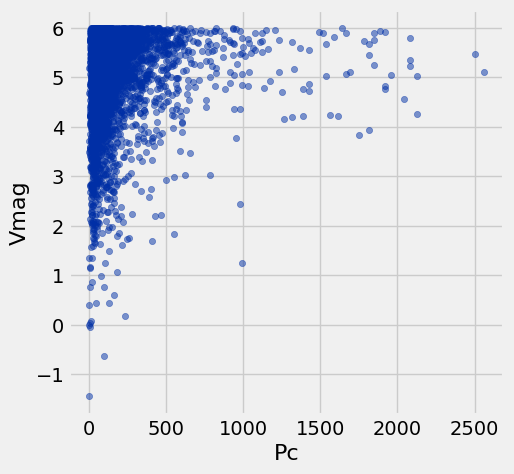

In [156]:
stars_4 = stars_2.where(1, are.below_or_equal_to(2600))
stars_4.where(2, are.below_or_equal_to(6)).scatter(1,2, alpha=0.5)

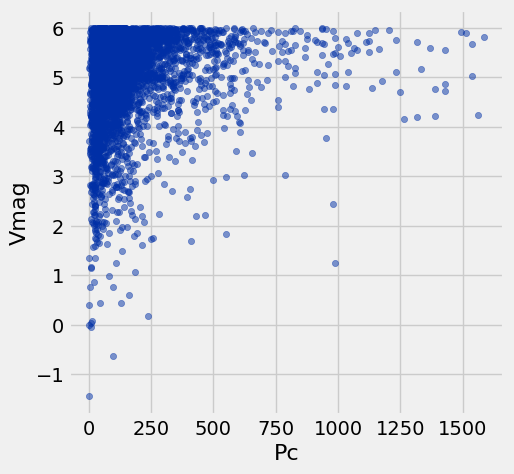

In [157]:
stars_5 = stars_2.where(1, are.below_or_equal_to(1600))
stars_5.where(2, are.below_or_equal_to(6)).scatter(1,2, alpha=0.5)

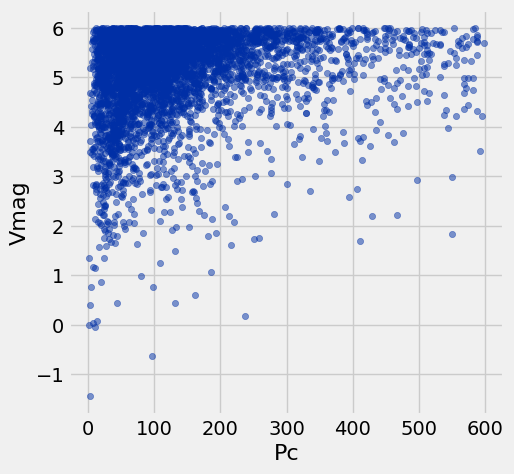

In [158]:
stars_6 = stars_2.where(1, are.below_or_equal_to(600))
stars_6.where(2, are.below_or_equal_to(6)).scatter(1,2, alpha=0.5)

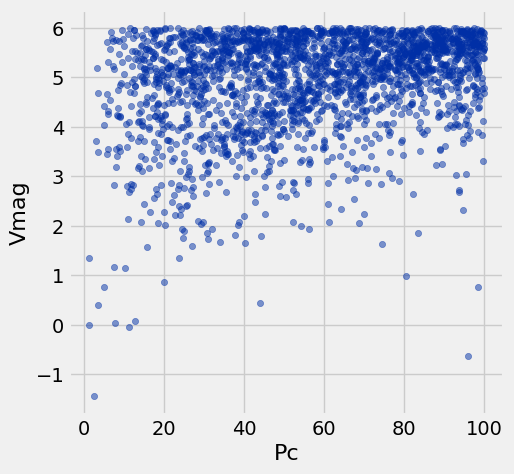

In [159]:
stars_7 = stars_2.where(1, are.below_or_equal_to(100))
stars_7.where(2, are.below_or_equal_to(6)).scatter(1,2, alpha=0.5)

In [160]:
stars_7.where(3, are.below_or_equal_to(6))

HIP,Pc,Vmag,ABSmag,Plx
2,45.6621,9.27,5.97222,21.9
7,56.3698,9.64,5.88477,17.74
10,92.9368,8.59,3.74906,10.76
20,92.9368,8.51,3.66906,10.76
23,81.9001,7.57,3.00358,12.21
25,72.7802,6.28,1.96993,13.74
34,78.6782,6.43,1.95073,12.71
38,41.9463,8.65,5.53653,23.84
39,91.0747,7.46,2.66301,10.98
45,66.2252,9.59,5.48488,15.1


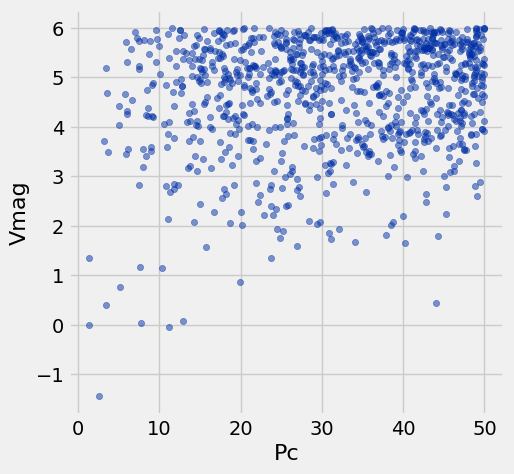

In [161]:
stars_8 = stars_2.where(1, are.below_or_equal_to(50))
stars_8.where(2, are.below_or_equal_to(6)).scatter(1,2, alpha=0.5)

In [162]:
len(stars_2.where(2, are.below(6)).column(2))

4960

In [163]:
len(stars_2.column(1))

112511

In [164]:
3.26*12500

40750.0

In [165]:
1000*3.26

3260.0

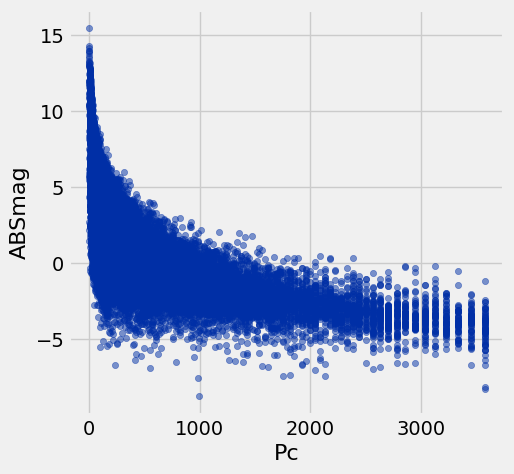

In [166]:
stars_2.scatter(1,3, alpha=0.5)

In [167]:
min(stars_2.column(3))

-8.7283931310867864

In [168]:
max(stars_2.column(3))

15.44901452341762

In [169]:
table2.select(0,1).scatter('x', fit_line = True) 

NameError: name 'table2' is not defined

## Polar Plots

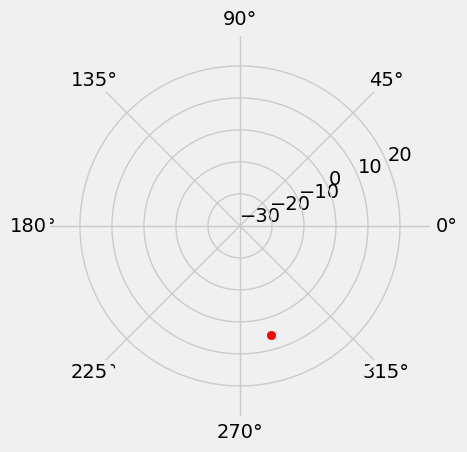

In [186]:
import numpy
import matplotlib.pyplot as pyplot



ra = 262.595 # [345.389547454166689,31.892236646759279,45.893722479722229,93.955296573703706,160.079453957685217,211.154701609814822,256.486559377222193,307.258751710462889,299.691923545370344,340.364168244814834,335.077343971296386,358.126565808425880]
dec = 5.54912 # [23.835021447037050,25.218513920000003,27.509148433518519,26.551432991388879,-25.077519630833340,-20.134061982500004,-21.042512836851849,-4.903512838240742,-0.506450475370370,14.280932901944448,19.222101837500002,18.792707990925926]   

fig = pyplot.figure()
ax = fig.add_axes([0.1,0.1,0.8,0.8],polar=True)
ax.set_ylim(-30,30)
ax.set_yticks(numpy.arange(-30,30,10))
ax.scatter(ra,dec,c ='r')


pyplot.show()    

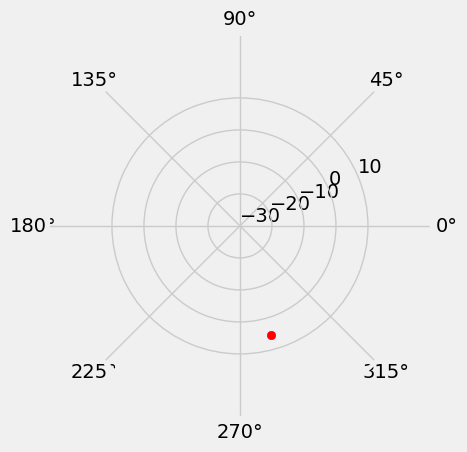

In [187]:
fig = pyplot.figure()
ax = fig.add_axes([0.1,0.1,0.8,0.8],polar=True)
ax.set_ylim(-30,30)
ax.set_yticks(numpy.arange(-30,20,10))
ax.scatter(ra,dec,c ='r')


pyplot.show()    

4.583147854638889


<>:54: SyntaxWarning: invalid escape sequence '\c'
<>:54: SyntaxWarning: invalid escape sequence '\c'
<>:54: SyntaxWarning: invalid escape sequence '\c'
<>:54: SyntaxWarning: invalid escape sequence '\c'
<>:55: SyntaxWarning: invalid escape sequence '\c'
<>:55: SyntaxWarning: invalid escape sequence '\c'
<>:55: SyntaxWarning: invalid escape sequence '\c'
<>:55: SyntaxWarning: invalid escape sequence '\c'
<>:55: SyntaxWarning: invalid escape sequence '\c'
<>:56: SyntaxWarning: invalid escape sequence '\c'
<>:56: SyntaxWarning: invalid escape sequence '\c'
<>:56: SyntaxWarning: invalid escape sequence '\c'
<>:56: SyntaxWarning: invalid escape sequence '\c'
<>:56: SyntaxWarning: invalid escape sequence '\c'
<>:57: SyntaxWarning: invalid escape sequence '\c'
<>:57: SyntaxWarning: invalid escape sequence '\c'
<>:57: SyntaxWarning: invalid escape sequence '\c'
<>:54: SyntaxWarning: invalid escape sequence '\c'
<>:54: SyntaxWarning: invalid escape sequence '\c'
<>:54: SyntaxWarning: invalid e

ValueError: The number of FixedLocator locations (10), usually from a call to set_ticks, does not match the number of labels (17).

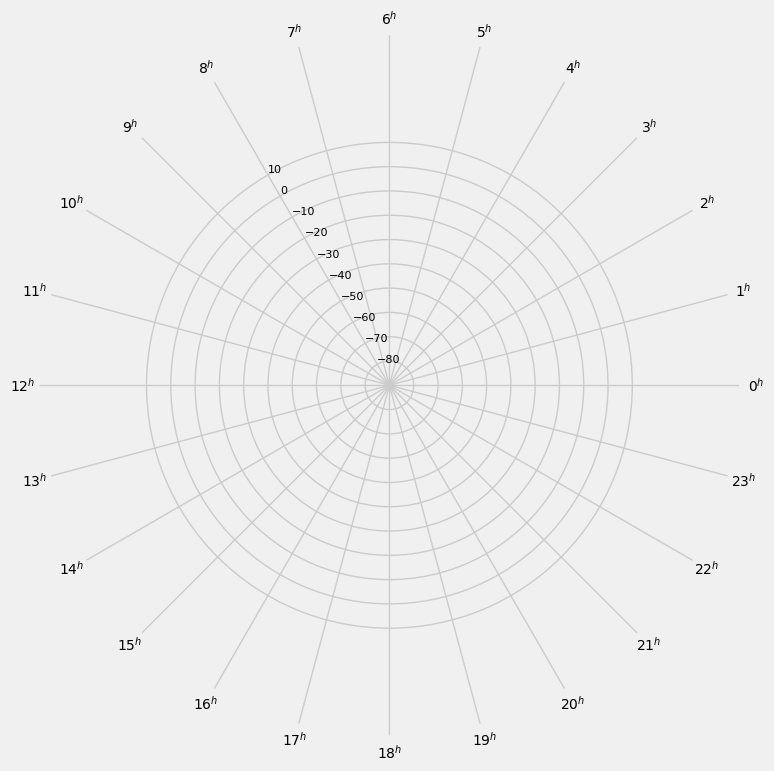

In [188]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def skip_comments(f):
    '''
    Read lines that DO NOT start with a # symbol.
    '''
    for line in f:
        if not line.strip().startswith('#'):
            yield line

def get_data_bb():
    '''RA, DEC data file.
    '''

    # Path to data file.
    out_file = 'bb_cat.dat'

    # Read data file
    with open(out_file) as f:
        ra, dec = [], []

        for line in skip_comments(f):
            ra.append(float(line.split()[0]))
            dec.append(float(line.split()[1]))

    return ra, dec

# Read RA, DEC data from file.
#ra, dec = get_data_bb()
# Convert RA from decimal degrees to radians.
#ra = [x / 180.0 * 3.141593 for x in ra]
ra = 262.595 / 180.0 * 3.141593
#ra =  17 30 22.71
print(ra)
      
# Make plot.
fig = plt.figure(figsize=(40, 40))
gs = gridspec.GridSpec(4, 2)
# Position plot in figure using gridspec.
ax = plt.subplot(gs[0], polar=True)
ax.set_ylim(-90, 55)

# Set x,y ticks
angs = np.array([330., 345., 0., 15., 30., 45., 60., 75., 90., 105., 120., 135., 150.,
                165., 180., 195., 210., 225., 240., 255., 270., 285., 300., 315.])
plt.xticks(angs * np.pi / 180., fontsize=8)
plt.yticks(np.arange(-80, 19, 10), fontsize=8)
ax.set_rlabel_position(120)
ax.set_xticklabels(['$22^h$', '$23^h$', '$0^h$', '$1^h$', '$2^h$', '$3^h$',
    '$4^h$', '$5^h$', '$6^h$', '$7^h$', '$8^h$', '$9^h$', '$10^h$', '$11^h$',
    '$12^h$', '$13^h$', '$14^h$', '$15^h$', '$16^h$', '$17^h$', '$18^h$', '$19^h$', '$20^h$', '$21^h$'], fontsize=10)
ax.set_yticklabels(['$-80^{\circ}$', '$-70^{\circ}$', '$-60^{\circ}$', '$-50^{\circ}$',
    '$-40^{\circ}$', '$-30^{\circ}$', '$-20^{\circ}$', '$-10^{\circ}$', '$0^{\circ}$',
    '$10^{\circ}$', '$20^{\circ}$', '$30^{\circ}$', '$40^{\circ}$', '$50^{\circ}$', 
    '$60^{\circ}$', '$70^{\circ}$', '$80^{\circ}$'],
    fontsize=8)

# Plot points.
ax.scatter(ra, dec, marker='o', c='k', s=15, lw=0.)

# Output png file.

#fig.tight_layout()
#plt.savefig(ra_dec_plot.png', dpi=300)